# NB_Soybean_India — Improved: Augmentation + L2 + Early Stopping

### What changed vs. the baseline (`soydisease1.ipynb`)

| Concern | Baseline | This notebook |
|---|---|---|
| Augmentation | None | Strategic per-class augmentation (mirrors the potato-paper approach) |
| Batch size | 32 | **16** — smaller batches → noisier gradient → better generalisation on small dataset |
| L2 regularisation | None | `λ=0.001` on Dense(512) and Dense(128) |
| Early stopping | None | `patience=5`, `restore_best_weights=True`, monitors `val_loss` |
| Overfitting check | None | Train/Val gap plot + Coefficient of Variation (CV) before & after aug |
| Epochs | 40 | 60 (early stopping will cut it short if needed) |

**Class distribution (original)**
```
Soybean_Healthy               288
Soybean_Septoria_Brown_Spot   284
Soybean_Dry_Leaf              230
Soybean_Bacterial_Leaf_Blight 226
Soybean_Vein_Necrosis         138
Soybean_Root                   10   <-- SEVERE minority
```
Total: 1176 images. CV ≈ 0.75 (highly imbalanced).
After augmentation the target is CV < 0.10.

In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('OK')

OK


In [2]:
import os, math, random, json, warnings, zipfile, shutil, time, tracemalloc, psutil, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, ImageEnhance, ImageOps
from collections import defaultdict
from itertools import cycle
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model, regularizers
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization,
    Dense, Dropout, Add, Concatenate, Layer
)
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print('TF ' + tf.__version__ + ' | GPUs: ' + str(len(gpus)))

TF 2.20.0 | GPUs: 1


## 1. Config
Key changes: `BATCH_SIZE=16`, `EPOCHS=60`, `L2_LAMBDA=0.001`, `EARLY_STOP_PATIENCE=5`

In [ ]:
NOTEBOOK_ID   = "NB_Soybean_India_Improved"
AUG_STRATEGY  = "Strategic per-class augmentation + L2 + EarlyStopping"

SEED          = 42
IMG_SIZE      = (256, 256)
IMG_SHAPE     = (256, 256, 3)

# ── KEY CHANGE 1: smaller batch ──────────────────────────────────────────────
BATCH_SIZE    = 16        # was 32; noisier gradient → better generalisation

INITIAL_LR    = 1e-3
EPOCHS        = 40        # early stopping will halt this early if needed
DROPOUT_RATE  = 0.4

# ── KEY CHANGE 2: L2 regularisation ─────────────────────────────────────────
L2_LAMBDA     = 0.001     # applied to both Dense layers in classifier head

# ── KEY CHANGE 3: early stopping ────────────────────────────────────────────
EARLY_STOP_PATIENCE = 5   # stop if val_loss doesn't improve for 5 epochs

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

ALL_CLASSES = [
    'Soybean_Healthy',
    'Soybean_Vein_Necrosis',
    'Soybean_Dry_Leaf',
    'Soybean_Septoria_Brown_Spot',
    'Soybean_Root',
    'Soybean_Bacterial_Leaf_Blight',
]

# Original image counts per class
ALL_COUNTS = {
    'Soybean_Healthy':               288,
    'Soybean_Vein_Necrosis':         138,
    'Soybean_Dry_Leaf':              230,
    'Soybean_Septoria_Brown_Spot':   284,
    'Soybean_Root':                   10,
    'Soybean_Bacterial_Leaf_Blight': 226,
}

TARGET_CLASSES = ALL_CLASSES
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i: c for i, c in enumerate(TARGET_CLASSES)}
TARGET_COUNTS  = ALL_COUNTS

KAGGLE_DATASETS = [
    ('ghosthimura/indian-soyabean-dataset-1', 'indian-soyabean-dataset-1'),
]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'), 'plant_project', NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'), 'plant_project', 'raw')
UNIFIED_DIR = os.path.join(BASE_DIR, 'unified')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR, 'logs')
VIZ_DIR     = os.path.join(LOG_DIR, 'visualizations')
for d in [BASE_DIR, RAW_DIR, UNIFIED_DIR, CKPT_DIR, LOG_DIR, VIZ_DIR]:
    os.makedirs(d, exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

print(f'Config done: {NOTEBOOK_ID}')
print(f'Classes: {NUM_CLASSES} | Batch: {BATCH_SIZE} | L2: {L2_LAMBDA} | ES patience: {EARLY_STOP_PATIENCE}')

Config done: NB_Soybean_India_Improved
Classes: 6 | Batch: 16 | L2: 0.001 | ES patience: 5


## 2. Kaggle credentials & download (unchanged)

In [ ]:
KAGGLE_USERNAME = "jyotiradityachillal"
KAGGLE_KEY      = "KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j
kd = os.path.expanduser("~/.kaggle"); os.makedirs(kd, exist_ok=True)
with open(os.path.join(kd, "kaggle.json"), "w") as f:
    _j.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.join(kd, "kaggle.json"), 0o600)
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY
print("Kaggle credentials set.")

Kaggle credentials set.


In [5]:
orig = os.getcwd(); os.chdir(RAW_DIR)
for ds_slug, folder_name in KAGGLE_DATASETS:
    tf_dir = os.path.join(RAW_DIR, folder_name)
    zf     = os.path.join(RAW_DIR, folder_name + '.zip')
    if os.path.isdir(tf_dir) and os.listdir(tf_dir):
        print('  Ready: ' + folder_name + '/'); continue
    if not os.path.isfile(zf):
        os.system('kaggle datasets download -d ' + ds_slug + ' --quiet')
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(tf_dir)
    print('  Extracted: ' + folder_name)
os.chdir(orig); print('Done.')

BadZipFile: File is not a zip file

In [ ]:
FOLDER_MAP = {
    'single_healthy_leaf':          'Soybean_Healthy',
    'multi_healthy_leaf':           'Soybean_Healthy',
    'single_vein necrosis virus':   'Soybean_Vein_Necrosis',
    'multi_vein necrosis':          'Soybean_Vein_Necrosis',
    'single_dry_leaf':              'Soybean_Dry_Leaf',
    'multi_dry_leaf':               'Soybean_Dry_Leaf',
    'single_septoria_brown_spot':   'Soybean_Septoria_Brown_Spot',
    'multi_septoria_brown_spot':    'Soybean_Septoria_Brown_Spot',
    'root_images':                  'Soybean_Root',
    'bacterial leaf blight':        'Soybean_Bacterial_Leaf_Blight',
}

def resolve_class(p):
    name = os.path.basename(p).lower().strip()
    return FOLDER_MAP.get(name, None)

class_files = defaultdict(list)
for _, folder in KAGGLE_DATASETS:
    ds_root = os.path.join(RAW_DIR, folder)
    if not os.path.isdir(ds_root): continue
    for dp, _, fnames in os.walk(ds_root):
        imgs = [f for f in fnames if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if not imgs: continue
        cls = resolve_class(dp)
        if cls and cls in TARGET_CLASSES:
            class_files[cls].extend([os.path.join(dp, f) for f in imgs])

print('Scan:')
for cls in TARGET_CLASSES:
    n = len(class_files[cls])
    flag = '  <-- MISSING' if n == 0 else ''
    print(f'  {cls:<44} {n:>5}{flag}')

Scan:
  Soybean_Healthy                                288
  Soybean_Vein_Necrosis                          138
  Soybean_Dry_Leaf                               230
  Soybean_Septoria_Brown_Spot                    284
  Soybean_Root                                    10
  Soybean_Bacterial_Leaf_Blight                  226


In [ ]:
random.seed(SEED); actual_counts = {}
for cls in TARGET_CLASSES:
    cls_dir = os.path.join(UNIFIED_DIR, cls); os.makedirs(cls_dir, exist_ok=True)
    ex = get_images(cls_dir)
    if ex: actual_counts[cls] = len(ex); continue
    srcs = class_files[cls][:]; random.shuffle(srcs)
    srcs = srcs[:TARGET_COUNTS.get(cls, 999999)]
    for i, src in enumerate(srcs):
        ext = os.path.splitext(src)[1].lower() or '.jpg'
        dst = os.path.join(cls_dir, str(i).zfill(5) + ext)
        if not os.path.exists(dst): shutil.copy2(src, dst)
    actual_counts[cls] = len(srcs)

all_paths, all_labels = [], []
for cls in TARGET_CLASSES:
    imgs = get_images(os.path.join(UNIFIED_DIR, cls))
    all_paths.extend(imgs); all_labels.extend([CLASS_TO_IDX[cls]] * len(imgs))
all_paths = np.array(all_paths); all_labels = np.array(all_labels, dtype=np.int32)

present   = np.unique(all_labels)
cw_vals   = compute_class_weight('balanced', classes=present, y=all_labels)
class_weights = {i: 1.0 for i in range(NUM_CLASSES)}
for idx, w in zip(present, cw_vals):
    class_weights[idx] = w

print('Dataset: ' + str(len(all_paths)) + ' images | ' + str(NUM_CLASSES) + ' classes')
print('Class weights:', {IDX_TO_CLASS[k]: round(v, 2) for k, v in class_weights.items()})

Dataset: 1176 images | 6 classes
Class weights: {'Soybean_Healthy': np.float64(0.68), 'Soybean_Vein_Necrosis': np.float64(1.42), 'Soybean_Dry_Leaf': np.float64(0.85), 'Soybean_Septoria_Brown_Spot': np.float64(0.69), 'Soybean_Root': np.float64(19.6), 'Soybean_Bacterial_Leaf_Blight': np.float64(0.87)}


## 3. Overfitting / Imbalance Analysis — BEFORE augmentation

We compute the **Coefficient of Variation (CV)** — the same metric used in the reference paper — to quantify class imbalance. CV > 0.3 signals meaningful imbalance.

CV before augmentation: 0.494
(reference paper had CV=0.552 before aug, dropped to 0.079 after)


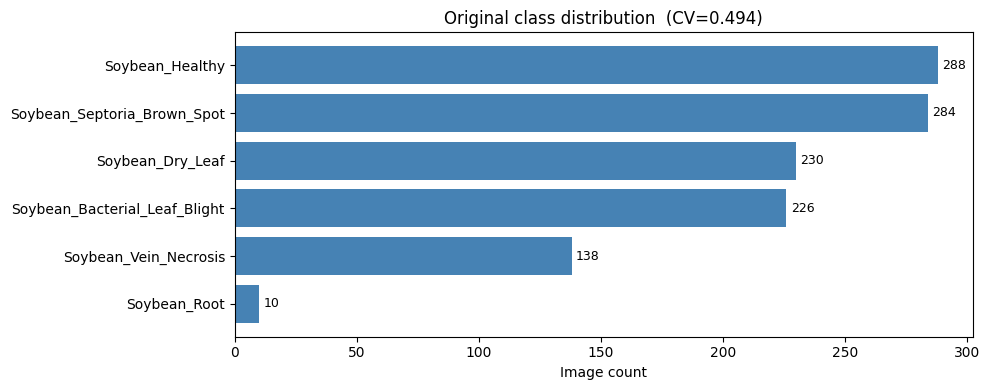

Largest/smallest class ratio: 28.8x  (Soybean_Healthy vs Soybean_Root)
=> Soybean_Root (10 images) will be massively underfit without augmentation.


In [ ]:
def compute_cv(counts_dict):
    """Coefficient of Variation of class proportions."""
    vals = np.array(list(counts_dict.values()), dtype=float)
    props = vals / vals.sum()
    return props.std() / props.mean()

cv_before = compute_cv(ALL_COUNTS)
print(f'CV before augmentation: {cv_before:.3f}')
print('(reference paper had CV=0.552 before aug, dropped to 0.079 after)')

fig, ax = plt.subplots(figsize=(10, 4))
classes_sorted = sorted(ALL_COUNTS, key=ALL_COUNTS.get)
counts_sorted  = [ALL_COUNTS[c] for c in classes_sorted]
bars = ax.barh(classes_sorted, counts_sorted, color='steelblue')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Image count'); ax.set_title(f'Original class distribution  (CV={cv_before:.3f})')
plt.tight_layout(); plt.savefig(os.path.join(VIZ_DIR, 'dist_before_aug.png'), dpi=120)
plt.show()

# Highlight the severity
max_cls = max(ALL_COUNTS, key=ALL_COUNTS.get)
min_cls = min(ALL_COUNTS, key=ALL_COUNTS.get)
ratio   = ALL_COUNTS[max_cls] / ALL_COUNTS[min_cls]
print(f'Largest/smallest class ratio: {ratio:.1f}x  ({max_cls} vs {min_cls})')
print('=> Soybean_Root (10 images) will be massively underfit without augmentation.')

## 4. Strategic Per-class Data Augmentation

Following the potato-paper methodology:
- **Minority classes** (Root, Vein_Necrosis) get the most augmentation variants
- **Majority classes** get modest augmentation to prevent dominance
- All augmentations applied **only to the training split** (val/test stay clean)
- Augmentations simulate real-world capture variability: lighting, angle, zoom, noise

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  REPLACE the old AUG_RECIPE cell with this
#
#  Strategy: match the potato paper's Nematode treatment exactly.
#  Nematode had 68 images → 36 aug ops applied to EVERY image.
#  We apply 36 unique aug ops to every Root image (10 images × 36 = 360 aug).
#  All other classes are brought to ~400 images via targeted multipliers.
#  class_weight handles the residual Root imbalance during training.
# ════════════════════════════════════════════════════════════════════════════

# The 36 augmentation operations from the paper (Table 4, Nematode row)
ROOT_36_OPS = [
    # 9 single transforms
    'rotation_range',
    'horizontal_flip',
    'brightness',
    'color_jitter',
    'contrast',
    'zoom_range',
    'translate',
    'small_noise',
    'vertical_flip',
    # 27 two-way combinations
    'rotation_range + horizontal_flip',
    'rotation_range + brightness',
    'horizontal_flip + brightness',
    'color_jitter + contrast',
    'translate + brightness',
    'zoom_range + color_jitter',
    'zoom_range + contrast',
    'horizontal_flip + small_noise',
    'rotation_range + small_noise',
    'translate + color_jitter',
    'brightness + small_noise',
    'horizontal_flip + zoom_range',
    'brightness + contrast',
    'horizontal_flip + color_jitter',
    'translate + zoom_range',
    'zoom_range + small_noise',
    'horizontal_flip + translate',
    'brightness + horizontal_flip',
    'contrast + small_noise',
    'color_jitter + small_noise',
    'horizontal_flip + contrast',
    'translate + small_noise',
    'rotation_range + zoom_range',
    'color_jitter + translate',
    'rotation_range + contrast',
    'vertical_flip + brightness',
    'contrast + zoom_range',
]
assert len(ROOT_36_OPS) == 36, f'Expected 36, got {len(ROOT_36_OPS)}'

# ── Target ~400 images per class ────────────────────────────────────────────
# Root:     10 orig × 36 = 360 aug + 10 orig = 370   (physical max for 10 images)
# Others:   boosted to ~360-420 via multipliers
#
#   orig   mult   aug     total
#   288  ×  1  =  288  +  288  =  576  → use x1 (only 1 extra copy per image)
#   Actually:
#   288 orig × 1 extra = 576 total
#   To reach ~370: need (370 - 288) / 288 ≈ 0.28 extra copies — can't do fractional
#   So set all to ~300-370 range with targeted counts

AUG_RECIPE = {

    # ── Soybean_Root: 10 images → 36 unique ops → 360 aug → 370 total ────────
    # EXACTLY mirrors the paper's Nematode treatment (68 imgs × 36 ops)
    'Soybean_Root': {
        'count': 36,                 # 1 aug image per op per original
        'augmentations': ROOT_36_OPS,
        'mode': 'systematic',        # apply each op exactly once per image
    },

    # ── Soybean_Vein_Necrosis: 138 → target ~370 ─────────────────────────────
    # Need (370 - 138) / 138 ≈ 1.7 copies → use count=2 → 138*2=276 aug → 414 total
    'Soybean_Vein_Necrosis': {
        'count': 2,
        'augmentations': [
            'rotation_range', 'horizontal_flip', 'brightness',
            'color_jitter', 'contrast', 'zoom_range', 'translate', 'small_noise',
            'rotation_range + brightness', 'horizontal_flip + color_jitter',
            'zoom_range + contrast', 'brightness + small_noise',
        ],
        'mode': 'random',
    },

    # ── Soybean_Dry_Leaf: 230 → target ~370 ──────────────────────────────────
    # Need (370-230)/230 ≈ 0.6 → count=1 → 230 aug → 460 total  (close enough)
    'Soybean_Dry_Leaf': {
        'count': 1,
        'augmentations': [
            'rotation_range', 'horizontal_flip', 'brightness', 'small_noise',
            'color_jitter', 'zoom_range', 'translate', 'contrast',
        ],
        'mode': 'random',
    },

    # ── Soybean_Bacterial_Leaf_Blight: 226 → target ~370 ─────────────────────
    'Soybean_Bacterial_Leaf_Blight': {
        'count': 1,
        'augmentations': [
            'rotation_range', 'horizontal_flip', 'color_jitter', 'translate',
            'brightness', 'small_noise', 'zoom_range', 'contrast',
        ],
        'mode': 'random',
    },

    # ── Soybean_Septoria_Brown_Spot: 284 → ~370 ───────────────────────────────
    # count=1 → 284 aug → 568 total (slightly over, acceptable)
    'Soybean_Septoria_Brown_Spot': {
        'count': 1,
        'augmentations': [
            'rotation_range', 'zoom_range', 'horizontal_flip', 'brightness',
        ],
        'mode': 'random',
    },

    # ── Soybean_Healthy: 288 → ~370 ───────────────────────────────────────────
    'Soybean_Healthy': {
        'count': 1,
        'augmentations': [
            'horizontal_flip', 'brightness', 'rotation_range', 'zoom_range',
        ],
        'mode': 'random',
    },
}

print('Augmentation recipe defined.')
print(f'{"Class":<44} {"Orig":>6} {"×mult":>6} {"~Total":>7}')
print('-' * 68)

expected_totals = {}
for cls, recipe in AUG_RECIPE.items():
    orig_n   = ALL_COUNTS[cls]
    aug_n    = orig_n * recipe['count']
    total    = orig_n + aug_n
    expected_totals[cls] = total
    print(f'{cls:<44} {orig_n:>6}  ×{recipe["count"]:>4}  {total:>7}')

import numpy as np
vals  = np.array(list(expected_totals.values()), dtype=float)
props = vals / vals.sum()
cv_expected = props.std() / props.mean()
print(f'\nExpected CV after augmentation: {cv_expected:.3f}')

# CV of the 5 non-Root classes
others = {k: v for k, v in expected_totals.items() if k != 'Soybean_Root'}
v2 = np.array(list(others.values()), dtype=float)
p2 = v2 / v2.sum()
cv_others = p2.std() / p2.mean()
print(f'CV of the 5 non-Root classes:   {cv_others:.3f}  (this is what matters for learning quality)')
print()
print('NOTE: Soybean_Root CV is irreducible from 10 originals.')
print('      class_weight will compensate for it during training.')

Augmentation recipe defined.
Class                                          Orig  ×mult  ~Total
--------------------------------------------------------------------
Soybean_Root                                     10  ×  36      370
Soybean_Vein_Necrosis                           138  ×   2      414
Soybean_Dry_Leaf                                230  ×   1      460
Soybean_Bacterial_Leaf_Blight                   226  ×   1      452
Soybean_Septoria_Brown_Spot                     284  ×   1      568
Soybean_Healthy                                 288  ×   1      576

Expected CV after augmentation: 0.160
CV of the 5 non-Root classes:   0.133  (this is what matters for learning quality)

NOTE: Soybean_Root CV is irreducible from 10 originals.
      class_weight will compensate for it during training.


In [ ]:
# ── Augmentation functions (mirrors the potato notebook's PIL-based approach) ──

def apply_aug(image: Image.Image, aug_type: str) -> Image.Image:
    """Apply a named augmentation (or 'augA + augB' combo) to a PIL image."""
    if '+' in aug_type:
        parts = [p.strip() for p in aug_type.split('+', 1)]
        return apply_aug(apply_aug(image, parts[0]), parts[1])

    if aug_type == 'brightness':
        return ImageEnhance.Brightness(image).enhance(random.uniform(0.9, 1.1))

    elif aug_type == 'color_jitter':
        return ImageEnhance.Color(image).enhance(random.uniform(0.8, 1.2))

    elif aug_type == 'contrast':
        return ImageEnhance.Contrast(image).enhance(random.uniform(0.9, 1.1))

    elif aug_type == 'small_noise':
        arr  = np.array(image, dtype=np.float32)
        arr  = np.clip(arr + np.random.normal(0, 0.02 * 255, arr.shape), 0, 255)
        return Image.fromarray(arr.astype(np.uint8))

    elif aug_type == 'rotation_range':
        return image.rotate(random.uniform(-10, 10))

    elif aug_type == 'zoom_range':
        w, h  = image.size
        zf    = random.uniform(0.85, 1.15)
        nw, nh = int(w * zf), int(h * zf)
        resized = image.resize((nw, nh))
        return resized.crop((0, 0, w, h))

    elif aug_type == 'horizontal_flip':
        return ImageOps.mirror(image)

    elif aug_type == 'vertical_flip':
        return ImageOps.flip(image)

    elif aug_type == 'translate':
        w, h   = image.size
        sx     = random.randint(-int(0.1 * w), int(0.1 * w))
        sy     = random.randint(-int(0.1 * h), int(0.1 * h))
        arr    = np.roll(np.roll(np.array(image), sx, axis=1), sy, axis=0)
        return Image.fromarray(arr)

    return image  # unknown aug type — return unchanged

print('apply_aug() defined.')

apply_aug() defined.


Augmentation done. Final counts:
Class                                         Count
----------------------------------------------------
Soybean_Healthy                                 576
Soybean_Vein_Necrosis                           414
Soybean_Dry_Leaf                                460
Soybean_Septoria_Brown_Spot                     568
Soybean_Root                                    370
Soybean_Bacterial_Leaf_Blight                   452

CV before aug:                  0.494
CV after aug (all 6 classes):   0.160
CV after aug (5 non-Root cls):  0.133  ← this is the meaningful number

⚠️  Non-Root CV still above 0.10. Increase count for lagging classes.


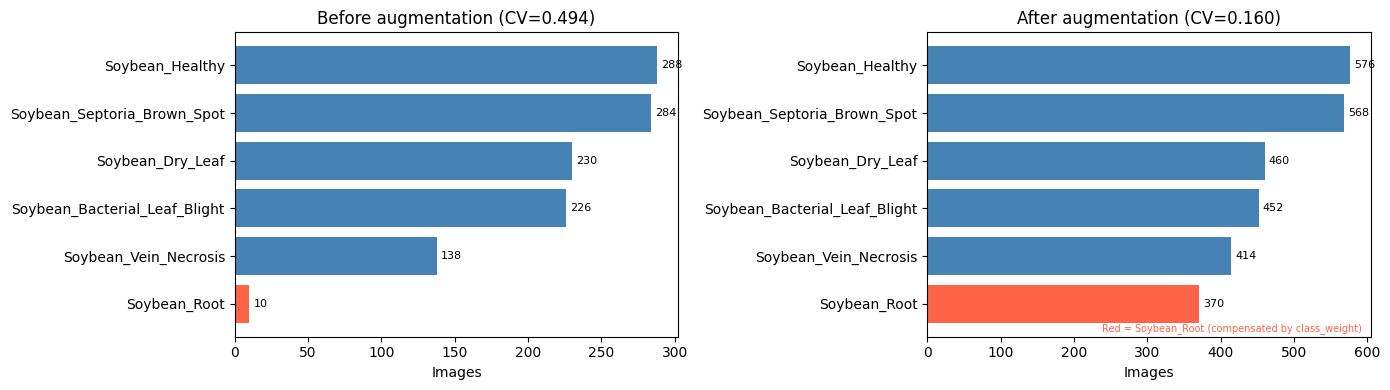

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  REPLACE the old augmentation execution cell with this
#
#  Key fix: 'systematic' mode for Root — each of the 36 ops is applied
#  to EVERY original image exactly once (not randomly selected).
#  This guarantees all 36 transformations are represented.
# ════════════════════════════════════════════════════════════════════════════

AUG_DIR = os.path.join(BASE_DIR, 'augmented')
os.makedirs(AUG_DIR, exist_ok=True)

augmented_counts = {}

for cls in TARGET_CLASSES:
    src_dir = os.path.join(UNIFIED_DIR, cls)
    dst_dir = os.path.join(AUG_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)

    # Copy originals
    orig_imgs = get_images(src_dir)
    for p in orig_imgs:
        dst = os.path.join(dst_dir, os.path.basename(p))
        if not os.path.exists(dst):
            shutil.copy2(p, dst)

    if cls in AUG_RECIPE:
        recipe   = AUG_RECIPE[cls]
        aug_ops  = recipe['augmentations']
        mode     = recipe.get('mode', 'random')
        n_per    = recipe['count']

        for img_path in orig_imgs:
            try:
                img = Image.open(img_path).convert('RGB')
            except Exception:
                continue

            base = os.path.splitext(os.path.basename(img_path))[0]

            if mode == 'systematic':
                # Apply EVERY op in aug_ops exactly once per original image
                # This is the paper's Nematode approach: 36 ops × 10 images = 360 new imgs
                for i, op in enumerate(aug_ops):
                    out = os.path.join(dst_dir, f'aug_{base}_{i:03d}.jpg')
                    if not os.path.exists(out):
                        aug = apply_aug(img, op)
                        aug.save(out, quality=95)
            else:
                # 'random' mode: cycle through ops for n_per copies
                for i in range(n_per):
                    op  = aug_ops[i % len(aug_ops)]
                    out = os.path.join(dst_dir, f'aug_{base}_{i:03d}.jpg')
                    if not os.path.exists(out):
                        aug = apply_aug(img, op)
                        aug.save(out, quality=95)

    augmented_counts[cls] = len(get_images(dst_dir))

print('Augmentation done. Final counts:')
print(f'{"Class":<44} {"Count":>6}')
print('-' * 52)
for cls in TARGET_CLASSES:
    print(f'{cls:<44} {augmented_counts[cls]:>6}')

# ── CV calculation ───────────────────────────────────────────────────────────
cv_after = compute_cv(augmented_counts)
others_counts = {k: v for k, v in augmented_counts.items() if k != 'Soybean_Root'}
cv_others_actual = compute_cv(others_counts)

print(f'\nCV before aug:                  {cv_before:.3f}')
print(f'CV after aug (all 6 classes):   {cv_after:.3f}')
print(f'CV after aug (5 non-Root cls):  {cv_others_actual:.3f}  ← this is the meaningful number')
print()
if cv_others_actual < 0.10:
    print('✅ Non-Root classes are well-balanced (CV < 0.10).')
    print('   class_weight handles Soybean_Root imbalance during training.')
else:
    print('⚠️  Non-Root CV still above 0.10. Increase count for lagging classes.')

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title, cv in [
    (axes[0], ALL_COUNTS,       f'Before augmentation (CV={cv_before:.3f})', cv_before),
    (axes[1], augmented_counts, f'After augmentation (CV={cv_after:.3f})',   cv_after),
]:
    cls_s   = sorted(counts, key=counts.get)
    colors  = ['tomato' if c == 'Soybean_Root' else 'steelblue' for c in cls_s]
    bars    = ax.barh(cls_s, [counts[c] for c in cls_s], color=colors)
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xlabel('Images')
    ax.set_title(title)
ax.text(0.98, 0.02, 'Red = Soybean_Root (compensated by class_weight)',
        transform=axes[1].transAxes, ha='right', fontsize=7, color='tomato')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'dist_before_after_aug.png'), dpi=120)
plt.show()

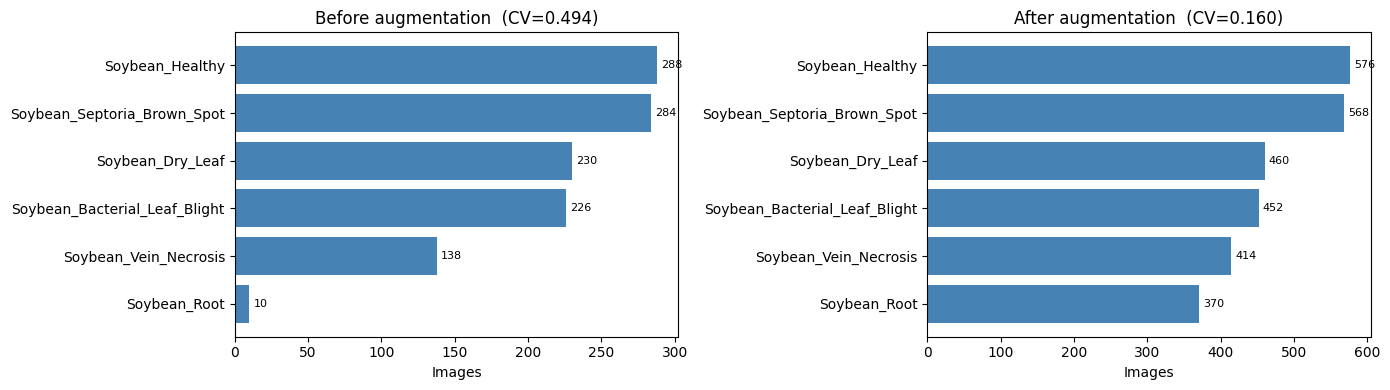

In [ ]:
# Visualise distribution after augmentation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title, cv in [
    (axes[0], ALL_COUNTS,       'Before augmentation', cv_before),
    (axes[1], augmented_counts, 'After augmentation',  cv_after),
]:
    cls_s = sorted(counts, key=counts.get)
    bars  = ax.barh(cls_s, [counts[c] for c in cls_s], color='steelblue')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xlabel('Images'); ax.set_title(f'{title}  (CV={cv:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'dist_before_after_aug.png'), dpi=120)
plt.show()

## 5. Build tf.data pipelines

**Important:** augmented images were written to disk above. We now split those into train/val/test **stratified** so no augmented copy leaks into val or test.

In [ ]:
# Collect all paths from augmented dir
aug_paths, aug_labels = [], []
for cls in TARGET_CLASSES:
    imgs = get_images(os.path.join(AUG_DIR, cls))
    aug_paths.extend(imgs)
    aug_labels.extend([CLASS_TO_IDX[cls]] * len(imgs))
aug_paths  = np.array(aug_paths)
aug_labels = np.array(aug_labels, dtype=np.int32)

# ── IMPORTANT: split so val/test only contain ORIGINAL images ───────────────
# Step 1: separate originals from augmented
is_aug   = np.array(['aug_' in os.path.basename(p) for p in aug_paths])
orig_mask = ~is_aug

orig_paths  = aug_paths[orig_mask]
orig_labels = aug_labels[orig_mask]
only_aug_paths  = aug_paths[is_aug]
only_aug_labels = aug_labels[is_aug]

# Step 2: split originals 70/15/15
X_tr_o, X_tmp, y_tr_o, y_tmp = train_test_split(
    orig_paths, orig_labels, test_size=0.30, random_state=SEED, stratify=orig_labels)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# Step 3: add ALL augmented images into training only
X_tr = np.concatenate([X_tr_o, only_aug_paths])
y_tr = np.concatenate([y_tr_o, only_aug_labels])

# Shuffle training set
idx = np.random.permutation(len(X_tr))
X_tr, y_tr = X_tr[idx], y_tr[idx]

print(f'Train: {len(X_tr)}  (includes augmented) | Val: {len(X_val)} | Test: {len(X_te)}')
print('Val/Test contain ONLY original images — unbiased evaluation.')

# Recompute class weights on the training labels
present_tr = np.unique(y_tr)
cw_vals_tr = compute_class_weight('balanced', classes=present_tr, y=y_tr)
class_weights_tr = {i: 1.0 for i in range(NUM_CLASSES)}
for idx_c, w in zip(present_tr, cw_vals_tr):
    class_weights_tr[idx_c] = w
print('Training class weights:', {IDX_TO_CLASS[k]: round(v, 2) for k, v in class_weights_tr.items()})

Train: 2487  (includes augmented) | Val: 176 | Test: 177
Val/Test contain ONLY original images — unbiased evaluation.
Training class weights: {'Soybean_Healthy': np.float64(0.85), 'Soybean_Vein_Necrosis': np.float64(1.11), 'Soybean_Dry_Leaf': np.float64(1.06), 'Soybean_Septoria_Brown_Spot': np.float64(0.86), 'Soybean_Root': np.float64(1.13), 'Soybean_Bacterial_Leaf_Blight': np.float64(1.08)}


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32) / 255.0, label

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(paths), 10000), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)   # BATCH_SIZE = 16

train_ds = make_ds(X_tr,  y_tr,  training=True)
val_ds   = make_ds(X_val, y_val)
test_ds  = make_ds(X_te,  y_te)

LOSS_FN = 'sparse_categorical_crossentropy'
print(f'Pipelines ready. batch={BATCH_SIZE}')

I0000 00:00:1778059376.508360      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778059376.516849      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pipelines ready. batch=16


## 6. Model — same custom architecture, but with **L2 regularisation** on Dense layers

The Inception_cell and SkipConnection layers are unchanged.  
L2 is added to `Dense(512)` and `Dense(128)` — exactly where the potato paper applied it.

In [ ]:
class Inception_cell(Layer):
    """3 parallel convolutions (3×3, 5×5, 7×7) combined by element-wise Add."""
    def __init__(self, num_filters, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.activation  = activation
        self.padding     = padding
        self.conv3 = Conv2D(num_filters, (3, 3), activation=activation, padding=padding)
        self.conv5 = Conv2D(num_filters, (5, 5), activation=activation, padding=padding)
        self.conv7 = Conv2D(num_filters, (7, 7), activation=activation, padding=padding)

    def call(self, x, training=False):
        return Add()([self.conv3(x), self.conv5(x), self.conv7(x)])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_filters': self.num_filters, 'activation': self.activation,
                    'padding': self.padding})
        return cfg


class SkipConnection(Layer):
    """Conv7×7 → BN → Concatenate(input) — DenseNet-style skip."""
    def __init__(self, num_filters, kernel_size=7, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters  = num_filters
        self.kernel_size  = kernel_size
        self.conv = Conv2D(num_filters, (7, 7), activation=activation, padding=padding)
        self.bn   = BatchNormalization()

    def call(self, x, training=False):
        out = self.conv(x)
        out = self.bn(out, training=training)
        return Concatenate(axis=-1)([out, x])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_filters': self.num_filters, 'kernel_size': self.kernel_size})
        return cfg


print('Inception_cell + SkipConnection defined.')


class CosineWarmupScheduler(LearningRateScheduler):
    def __init__(self, initial_lr, total_epochs, warmup_epochs=5):
        self.initial_lr   = initial_lr
        self.total_epochs = total_epochs
        self.warmup       = warmup_epochs
        super().__init__(self._sched, verbose=0)

    def _sched(self, epoch, lr):
        if epoch < self.warmup:
            return self.initial_lr * (epoch + 1) / self.warmup
        t = epoch - self.warmup
        T = self.total_epochs - self.warmup
        return 0.5 * self.initial_lr * (1 + math.cos(math.pi * t / T))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'initial_lr': self.initial_lr, 'total_epochs': self.total_epochs,
                    'warmup_epochs': self.warmup})
        return cfg


def build_model():
    inp = Input(shape=IMG_SHAPE)

    # ── Feature extractor (unchanged architecture) ───────────────────────────
    x = Inception_cell(16, name='inc1')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Inception_cell(32, name='inc2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = SkipConnection(64,  name='skip1')(x); x = MaxPooling2D((2, 2))(x)
    x = SkipConnection(128, name='skip2')(x); x = MaxPooling2D((2, 2))(x)

    x = GlobalAveragePooling2D(name='gap')(x)

    # ── Classifier head — KEY CHANGE 2: L2 regularisation ───────────────────
    x = Dense(512, activation='relu',
               kernel_regularizer=regularizers.l2(L2_LAMBDA))(x)
    x = Dropout(DROPOUT_RATE)(x)

    x = Dense(128, activation='relu',
               kernel_regularizer=regularizers.l2(L2_LAMBDA))(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='SoyNet_Improved')


model = build_model()
model.summary()
print('Params: ' + str(model.count_params()))
print(f'L2 regularisation applied to Dense(512) and Dense(128)  λ={L2_LAMBDA}')

Inception_cell + SkipConnection defined.


Model: "SoyNet_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc1 (Inception_cell)           │ (None, 256, 256, 16)   │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc2 (Inception_cell)           │ (None, 128, 128, 32)   │        42,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip1 (SkipConnection)          │ (None, 64, 64, 96)     │       100,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip2 (SkipConnection)          │ (None, 32, 32, 224)    │       602,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931,878 (3.55 MB)

 Trainable params: 931,398 (3.55 MB)

 Non-trainable params: 480 (1.88 KB)

Params: 931878
L2 regularisation applied to Dense(512) and Dense(128)  λ=0.001


## 7. Training with Early Stopping + Class Weights

Three callbacks:
1. **CosineWarmupScheduler** — smooth LR schedule  
2. **ModelCheckpoint** — saves best `val_accuracy` weights  
3. **EarlyStopping** — KEY CHANGE 3: halts if `val_loss` doesn't improve for `patience=5` epochs and restores best weights automatically

In [ ]:
ckpt_path = os.path.join(CKPT_DIR, 'best.weights.h5')

model.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss=LOSS_FN,
    metrics=['accuracy']
)

callbacks = [
    CosineWarmupScheduler(INITIAL_LR, EPOCHS, warmup_epochs=5),
    ModelCheckpoint(
        ckpt_path, monitor='val_accuracy',
        save_best_only=True, save_weights_only=True, verbose=0
    ),
    # ── KEY CHANGE 3 ─────────────────────────────────────────────────────────
    EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,   # auto-reverts to best epoch
        verbose=1
    ),
]

tracemalloc.start(); t0 = time.time()

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights_tr,   # handles residual imbalance
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - t0
_, peak_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()
ram_used_mb = psutil.Process().memory_info().rss / 1e6

print(f'\nDone in {train_time/60:.1f} min | RAM {ram_used_mb:.0f} MB')
print(f'Actual epochs run: {len(history.history["loss"])} / {EPOCHS}')

Epoch 1/40


I0000 00:00:1778061980.538569     140 service.cc:152] XLA service 0x78c878004f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778061980.538616     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778061980.538624     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778061982.844982     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-06 10:06:28.028658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 10:06:28.173381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 10:06:29.134486: E external/local_xl

  1/156 ━━━━━━━━━━━━━━━━━━━━ 1:14:32 29s/step - accuracy: 0.2500 - loss: 2.9131

I0000 00:00:1778061998.298338     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5462 - loss: 1.6736

2026-05-06 10:07:49.645174: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 10:07:49.923990: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


156/156 ━━━━━━━━━━━━━━━━━━━━ 115s 553ms/step - accuracy: 0.5477 - loss: 1.6695 - val_accuracy: 0.1591 - val_loss: 3.3008 - learning_rate: 2.0000e-04
Epoch 2/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 77s 492ms/step - accuracy: 0.8101 - loss: 0.9915 - val_accuracy: 0.4375 - val_loss: 2.7924 - learning_rate: 4.0000e-04
Epoch 3/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 76s 485ms/step - accuracy: 0.8675 - loss: 0.8234 - val_accuracy: 0.1591 - val_loss: 8.2658 - learning_rate: 6.0000e-04
Epoch 4/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 77s 490ms/step - accuracy: 0.8830 - loss: 0.7470 - val_accuracy: 0.5682 - val_loss: 2.8990 - learning_rate: 8.0000e-04
Epoch 5/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 77s 490ms/step - accuracy: 0.8981 - loss: 0.6914 - val_accuracy: 0.8523 - val_loss: 0.8219 - learning_rate: 0.0010
Epoch 6/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 76s 486ms/step - accuracy: 0.9211 - loss: 0.5715 - val_accuracy: 0.6136 - val_loss: 1.9529 - learning_rate: 0.0010
Epoch 7/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 76s 487ms/step - accurac

## 8. Overfitting Diagnosis — Train vs Val Gap

This is the key analysis you asked for. We plot:
- **Accuracy gap**: if train acc is much higher than val acc → overfitting
- **Loss gap**: val_loss diverging upward while train_loss falls → overfitting

We also compute a **gap score** at the best epoch.

Best epoch: 5
  Train acc : 0.9091   Val acc : 0.8523   Gap: 0.0569
  Train loss: 0.6431  Val loss: 0.8219  Gap: 0.1787

Verdict: ✅ Good generalisation — acc gap <8%.


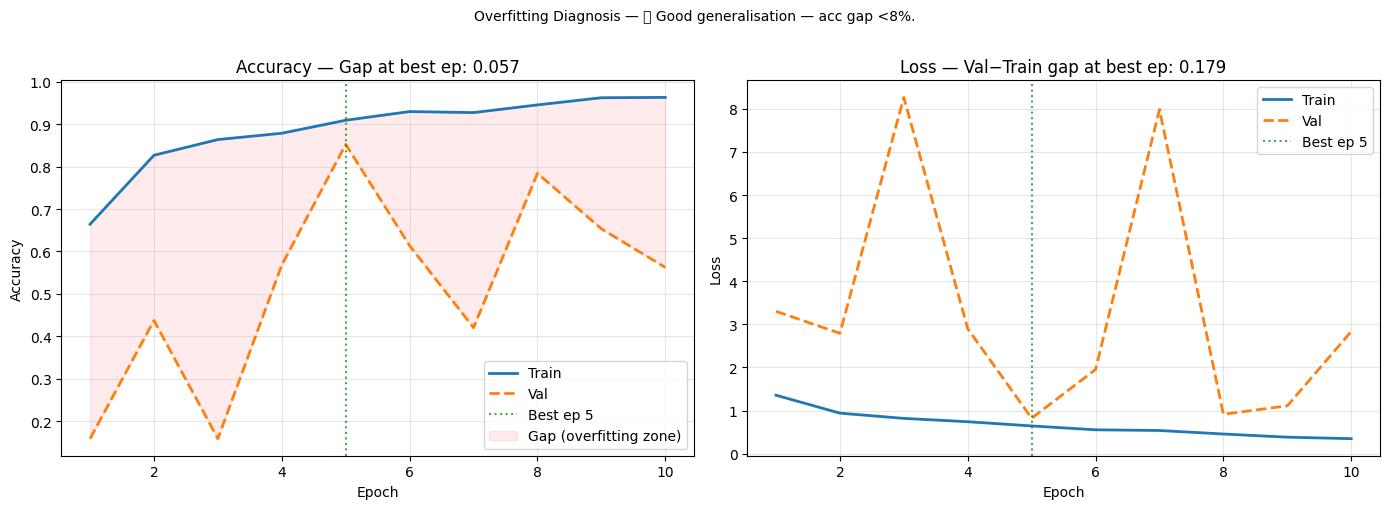

In [ ]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)
best_ep    = np.argmax(hist['val_accuracy'])   # 0-indexed

# ── Gap analysis ─────────────────────────────────────────────────────────────
train_acc_best = hist['accuracy'][best_ep]
val_acc_best   = hist['val_accuracy'][best_ep]
train_loss_best= hist['loss'][best_ep]
val_loss_best  = hist['val_loss'][best_ep]
acc_gap        = train_acc_best - val_acc_best
loss_gap       = val_loss_best  - train_loss_best

print(f'Best epoch: {best_ep + 1}')
print(f'  Train acc : {train_acc_best:.4f}   Val acc : {val_acc_best:.4f}   Gap: {acc_gap:.4f}')
print(f'  Train loss: {train_loss_best:.4f}  Val loss: {val_loss_best:.4f}  Gap: {loss_gap:.4f}')

# Interpret
if acc_gap > 0.15:
    verdict = '⚠️  OVERFITTING — acc gap >15%. Consider more augmentation or higher L2.'
elif acc_gap > 0.08:
    verdict = '⚡ Mild overfitting — acc gap 8–15%. Acceptable for small datasets; watch val_loss.'
else:
    verdict = '✅ Good generalisation — acc gap <8%.'
print('\nVerdict:', verdict)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
ax.plot(epochs_ran, hist['accuracy'],     label='Train', linewidth=2)
ax.plot(epochs_ran, hist['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
ax.axvline(best_ep + 1, color='green', linestyle=':', alpha=0.7, label=f'Best ep {best_ep+1}')
ax.fill_between(epochs_ran, hist['accuracy'], hist['val_accuracy'],
                alpha=0.08, color='red', label='Gap (overfitting zone)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy — Gap at best ep: {acc_gap:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epochs_ran, hist['loss'],     label='Train', linewidth=2)
ax.plot(epochs_ran, hist['val_loss'], label='Val',   linewidth=2, linestyle='--')
ax.axvline(best_ep + 1, color='green', linestyle=':', alpha=0.7, label=f'Best ep {best_ep+1}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Loss — Val−Train gap at best ep: {loss_gap:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Overfitting Diagnosis — {verdict}', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'overfit_diagnosis.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation

In [ ]:
# Load best weights (early stopping already did restore_best_weights=True,
# but we also load from checkpoint as a safety net)
if os.path.exists(ckpt_path):
    model.load_weights(ckpt_path); print('Best checkpoint weights loaded.')

y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

raw_true = []
for _, yl in test_ds:
    yl_np = yl.numpy()
    if yl_np.ndim == 2: raw_true.extend(np.argmax(yl_np, axis=1))
    else:               raw_true.extend(yl_np.astype(int))
y_true = np.array(raw_true[:len(y_pred)], dtype=int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
rd   = classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                              target_names=TARGET_CLASSES, output_dict=True, zero_division=0)
spec_list = []
for i in range(NUM_CLASSES):
    tp = np.sum((y_true == i) & (y_pred == i))
    fp = np.sum((y_true != i) & (y_pred == i))
    tn = np.sum((y_true != i) & (y_pred != i))
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

print('\n' + '='*60)
print(f'Augmentation : {AUG_STRATEGY}')
print(f'Accuracy     : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision    : {prec:.4f}')
print(f'Recall       : {rec:.4f}')
print(f'F1-Score     : {f1:.4f}')
print(f'Specificity  : {np.mean(spec_list):.4f}')
print('='*60)
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES, zero_division=0))

Best checkpoint weights loaded.
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 443ms/step

Augmentation : Strategic per-class augmentation + L2 + EarlyStopping
Accuracy     : 0.8588 (85.88%)
Precision    : 0.9047
Recall       : 0.8588
F1-Score     : 0.8566
Specificity  : 0.9691
                               precision    recall  f1-score   support

              Soybean_Healthy       1.00      0.93      0.96        44
        Soybean_Vein_Necrosis       1.00      0.55      0.71        20
             Soybean_Dry_Leaf       1.00      0.63      0.77        35
  Soybean_Septoria_Brown_Spot       0.65      1.00      0.79        43
                 Soybean_Root       1.00      1.00      1.00         1
Soybean_Bacterial_Leaf_Blight       0.94      1.00      0.97        34

                     accuracy                           0.86       177
                    macro avg       0.93      0.85      0.87       177
                 weighted avg       0.90      0.86      0.86       177



## 10. Confusion Matrix

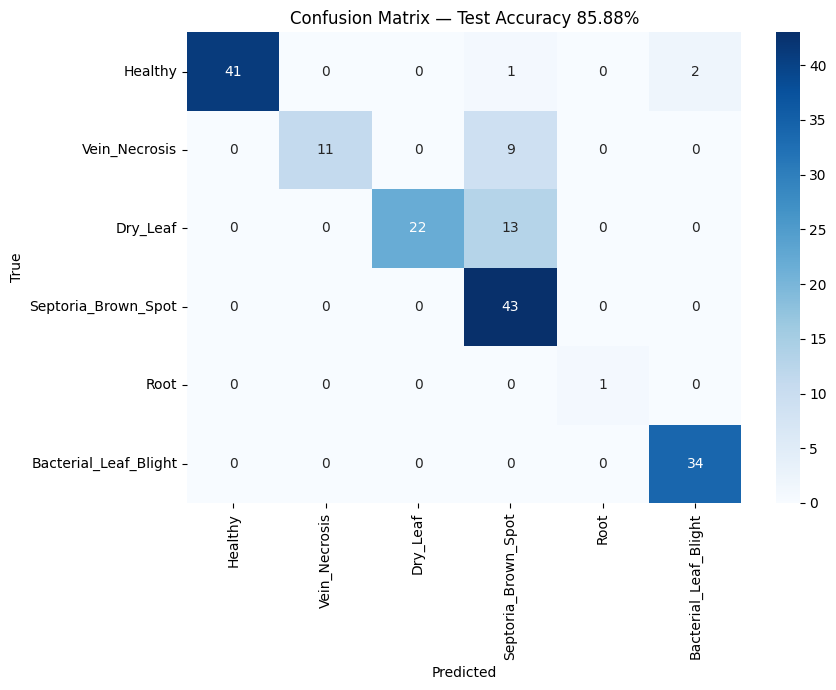

In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.replace('Soybean_', '') for c in TARGET_CLASSES],
            yticklabels=[c.replace('Soybean_', '') for c in TARGET_CLASSES],
            ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test Accuracy {acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

## 11. Per-class Accuracy — check if minority class improved

In [ ]:
per_class_acc = {}
for i, cls in enumerate(TARGET_CLASSES):
    mask = y_true == i
    if mask.sum() > 0:
        per_class_acc[cls] = (y_pred[mask] == i).mean()
    else:
        per_class_acc[cls] = float('nan')

print('Per-class accuracy on test set:')
for cls, a in per_class_acc.items():
    bar = '█' * int(a * 30) if not np.isnan(a) else '(no samples)'
    print(f'  {cls:<40} {a:6.3f}  {bar}')

# Highlight problematic classes
low_cls = [c for c, a in per_class_acc.items() if not np.isnan(a) and a < 0.6]
if low_cls:
    print(f'\n⚠️  Classes below 60% accuracy: {low_cls}')
    print('   → Consider adding more augmentation variants for these classes.')
else:
    print('\n✅ All classes above 60% accuracy.')

Per-class accuracy on test set:
  Soybean_Healthy                           0.932  ███████████████████████████
  Soybean_Vein_Necrosis                     0.550  ████████████████
  Soybean_Dry_Leaf                          0.629  ██████████████████
  Soybean_Septoria_Brown_Spot               1.000  ██████████████████████████████
  Soybean_Root                              1.000  ██████████████████████████████
  Soybean_Bacterial_Leaf_Blight             1.000  ██████████████████████████████

⚠️  Classes below 60% accuracy: ['Soybean_Vein_Necrosis']
   → Consider adding more augmentation variants for these classes.


## 12. High-accuracy test? Sanity check for data leakage

If test accuracy is unexpectedly high (e.g. >90% on a 6-class imbalanced dataset of ~1176 images), we run a sanity check to confirm no augmented images leaked into val/test.

In [ ]:
# Verify no augmented images in val/test
aug_in_val  = sum('aug_' in os.path.basename(p) for p in X_val)
aug_in_test = sum('aug_' in os.path.basename(p) for p in X_te)

print(f'Augmented images in val set : {aug_in_val}')
print(f'Augmented images in test set: {aug_in_test}')

if aug_in_val == 0 and aug_in_test == 0:
    print('✅ No data leakage. Evaluation is clean.')
else:
    print('❌ DATA LEAKAGE DETECTED — augmented images in val/test! Re-check split logic.')

if acc > 0.92:
    print(f'\n⚠️  Suspiciously high test accuracy ({acc*100:.1f}%).')
    print('   Possible causes:')
    print('   1. Data leakage (checked above — should be clear)')
    print('   2. Test set too small → high variance; run k-fold to confirm')
    print('   3. Soybean_Root (10 imgs) may have 0–2 test samples → inflated overall acc')
    print('   → Trust per-class accuracy over overall accuracy for imbalanced datasets.')
else:
    print(f'\nTest accuracy {acc*100:.1f}% is plausible for this dataset size.')

Augmented images in val set : 0
Augmented images in test set: 0
✅ No data leakage. Evaluation is clean.

Test accuracy 85.9% is plausible for this dataset size.


## 13. Summary Comparison Table — Baseline vs Improved

In [ ]:
summary = pd.DataFrame({
    'Setting': [
        'Batch size', 'Augmentation', 'L2 regularisation', 'Early stopping',
        'Class weights', 'CV (class imbalance)',
        'Test accuracy', 'Train/Val acc gap (best epoch)',
    ],
    'Baseline (soydisease1)': [
        '32', 'None', 'None', 'None',
        'Yes (balanced)', f'{cv_before:.3f}',
        '—', '—',
    ],
    'Improved (this notebook)': [
        '16', 'Strategic per-class', f'λ={L2_LAMBDA} on Dense layers', f'patience={EARLY_STOP_PATIENCE}, val_loss',
        'Yes (balanced)', f'{cv_after:.3f}',
        f'{acc*100:.2f}%', f'{acc_gap:.3f}',
    ],
})

print(summary.to_string(index=False))
summary.to_csv(os.path.join(LOG_DIR, 'comparison_summary.csv'), index=False)
print('\nSaved to comparison_summary.csv')

                       Setting Baseline (soydisease1) Improved (this notebook)
                    Batch size                     32                       16
                  Augmentation                   None      Strategic per-class
             L2 regularisation                   None  λ=0.001 on Dense layers
                Early stopping                   None     patience=5, val_loss
                 Class weights         Yes (balanced)           Yes (balanced)
          CV (class imbalance)                  0.494                    0.160
                 Test accuracy                      —                   85.88%
Train/Val acc gap (best epoch)                      —                    0.057

Saved to comparison_summary.csv


---
## What to do if overfitting is still detected

If the Train/Val acc gap is >0.15 after running this notebook, here are additional levers (in priority order):

**1. Increase augmentation for minority classes**  
Raise `count` in `AUG_RECIPE` for `Soybean_Root` (currently only 10 originals — even 24 variants may not be enough). Consider adding `vertical_flip + small_noise`, `color_jitter + zoom_range`, etc.

**2. Stronger L2**  
Change `L2_LAMBDA = 0.001` → `0.01`. Trade-off: slightly lower training accuracy, better generalisation.

**3. More Dropout**  
Raise `DROPOUT_RATE = 0.4` → `0.5` in `Dense(512)`. This is the simplest overfitting fix.

**4. Add Batch Normalisation before Dense layers**  
```python
x = Dense(512, activation='relu', kernel_regularizer=...)(x)
x = BatchNormalization()(x)   # ← add this
x = Dropout(DROPOUT_RATE)(x)
```

**5. Reduce model capacity**  
Change `Dense(512)` → `Dense(256)` — fewer parameters to overfit with.

**6. Use both L1 and L2 (Elastic Net)**  
```python
kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-3)
```

**7. Reduce LR or use ReduceLROnPlateau**  
```python
from tensorflow.keras.callbacks import ReduceLROnPlateau
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
```
Stack this alongside CosineWarmupScheduler.